<div class="fa-rtl" dir="rtl">

# Machine Learning with Python — Session 2
## Linear Regression & Correlation

**مدرس:** Hamed Naseri  
**مدت:** ۲ ساعت  
**Dataset اصلی:** Scikit-learn Diabetes Dataset — داده واقعی  


---

### هدف جلسه

در پایان این جلسه انتظار می‌رود دانشجو بتواند:

1. تمرین اصلی و Homework جلسه قبل را به‌صورت کامل حل و تفسیر کند.
2. تفاوت **Simple** و **Multiple Linear Regression** را توضیح دهد.
3. Regression Coefficientها را تفسیر کند.
4. Residual و Least Squares را بفهمد.
5. Assumptionهای اصلی Linear Regression را بررسی کند.
6. Pearson و Spearman Correlation را محاسبه و مقایسه کند.
7. Correlation Matrix و Heatmap بسازد.
8. تفاوت **Correlation** و **Causation** را توضیح دهد.
9. `MAE`, `MSE`, `RMSE`, `R²` را محاسبه و تفسیر کند.

</div>

<div class="fa-rtl" dir="rtl">

# 1. Setup و Dataset واقعی

در کل این جلسه از **Diabetes Dataset** موجود در Scikit-learn استفاده می‌کنیم.

این Dataset شامل:

- **442 Observation**
- **10 Baseline Feature**
- یک Target عددی مربوط به **میزان پیشرفت بیماری یک سال بعد از baseline**

است.

Featureهای اصلی:

- `age`
- `sex`
- `bmi`
- `bp`
- `s1` تا `s6`

در این Notebook از `scaled=False` استفاده می‌کنیم تا Featureهایی مثل BMI و Blood Pressure در مقیاس خام باشند و تفسیر Coefficientها ساده‌تر شود.

</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

In [ ]:
# Real dataset
diabetes = load_diabetes(as_frame=True, scaled=False)

df = diabetes.frame.copy()

print("Shape:", df.shape)
display(df.head())
#display(df)

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


In [ ]:
print("Feature names:")
print(diabetes.feature_names)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary:")
display(df.describe().round(1))

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Missing values:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0



Summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0
mean,48.5,1.5,26.4,94.6,189.1,115.4,49.8,4.1,4.6,91.3,152.1
std,13.1,0.5,4.4,13.8,34.6,30.4,12.9,1.3,0.5,11.5,77.1
min,19.0,1.0,18.0,62.0,97.0,41.6,22.0,2.0,3.3,58.0,25.0
25%,38.2,1.0,23.2,84.0,164.2,96.0,40.2,3.0,4.3,83.2,87.0
50%,50.0,1.0,25.7,93.0,186.0,113.0,48.0,4.0,4.6,91.0,140.5
75%,59.0,2.0,29.3,105.0,209.8,134.5,57.8,5.0,5.0,98.0,211.5
max,79.0,2.0,42.2,133.0,301.0,242.4,99.0,9.1,6.1,124.0,346.0


<div class="fa-rtl" dir="rtl">

# 2. حل تمرین‌های جلسه قبل

ابتدا سه بخش اصلی جلسه قبل را کامل حل می‌کنیم:

1. **Complete ML Workflow با Feature = `bmi`**
2. **Challenge: مقایسه Featureهای تک‌متغیره**
3. **Homework: سه Feature + Baseline + Linear Regression + Evaluation + Plot**

همه Splitها:

```python
test_size=0.2
random_state=0
```

خواهند بود.

</div>

<div class="fa-rtl" dir="rtl">

## 2.1 حل تمرین اصلی جلسه اول

تمرین:

- فقط `bmi` به‌عنوان Feature
- Mean Baseline
- Linear Regression
- مقایسه MAE
- محاسبه R²

</div>

In [ ]:
# STEP 1 — Define X and y
X_one = df[["bmi"]]
y_one = df["target"]

X_one.head()


,bmi
0,32.1
1,21.6
2,30.5
3,25.3
4,23.0


In [ ]:
# STEP 2 — Train/Test Split
X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(
    X_one,
    y_one,
    test_size=0.2,
    random_state=0
)

print("Train shape:", X_train_one.shape)
print("Test shape:", X_test_one.shape)

Train shape: (353, 1)
Test shape: (89, 1)


In [ ]:
# STEP 3 — Baseline
baseline_one = DummyRegressor(strategy="mean")
baseline_one.fit(X_train_one, y_train_one)

baseline_one_pred = baseline_one.predict(X_test_one)

In [ ]:
# STEP 4 — Linear Regression
model_one = LinearRegression()
model_one.fit(X_train_one, y_train_one)

y_pred_one = model_one.predict(X_test_one)

In [ ]:
# STEP 5 — Evaluate and compare
baseline_mae = mean_absolute_error(y_test_one, baseline_one_pred)
baseline_r2 = r2_score(y_test_one, baseline_one_pred)
model_mae = mean_absolute_error(y_test_one, y_pred_one)
model_r2 = r2_score(y_test_one, y_pred_one)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline R²: {baseline_r2:.3f}")
print(f"Linear Regression MAE: {model_mae:.2f}")
print(f"Linear Regression R²: {model_r2:.3f}")

Baseline MAE: 59.23
Baseline R²: -0.001
Linear Regression MAE: 52.94
Linear Regression R²: 0.191


<div class="fa-rtl" dir="rtl">

### تفسیر جواب

با `random_state=0` تقریباً داریم:

- **Baseline MAE ≈ 59.23**
- **Linear Regression MAE ≈ 52.94**
- **R² ≈ 0.191**

پس:

> مدل تک‌متغیره `bmi` از Mean Baseline بهتر عمل می‌کند، چون MAE آن کمتر است.

اما R² نشان می‌دهد `bmi` به‌تنهایی بخش بزرگی از variation مربوط به Target را توضیح نمی‌دهد.

این دقیقاً دلیل خوبی برای ورود به **Multiple Linear Regression** است.

</div>

<div class="fa-rtl" dir="rtl">

## 2.2 حل Challenge جلسه قبل

Challenge می‌گفت یک Feature دیگر انتخاب کنید و مدل‌های تک‌متغیره را مقایسه کنید.

اینجا حرفه‌ای‌تر عمل می‌کنیم:

> تمام Featureهای Dataset را یکی‌یکی امتحان می‌کنیم و Test MAE و R² هرکدام را مقایسه می‌کنیم.

</div>

In [ ]:
for feature in diabetes.feature_names:

    X = df[[feature]]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(feature)
    print("MAE:", round(mae, 2))
    print("R2:", round(r2, 3))
    print("----------------")

age
MAE: 58.09
R2: 0.034
----------------
sex
MAE: 58.97
R2: 0.002
----------------
bmi
MAE: 52.94
R2: 0.191
----------------
bp
MAE: 49.83
R2: 0.187
----------------
s1
MAE: 56.61
R2: 0.048
----------------
s2
MAE: 56.84
R2: 0.05
----------------
s3
MAE: 59.31
R2: 0.006
----------------
s4
MAE: 55.48
R2: 0.109
----------------
s5
MAE: 51.46
R2: 0.198
----------------
s6
MAE: 53.82
R2: 0.148
----------------


In [ ]:
single_feature_results = []

for feature in diabetes.feature_names:
    X_f = df[[feature]]
    y_f = df["target"]

    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_f,
        y_f,
        test_size=0.2,
        random_state=0
    )

    model_f = LinearRegression()
    model_f.fit(X_train_f, y_train_f)
    pred_f = model_f.predict(X_test_f)

    single_feature_results.append({
        "feature": feature,
        "MAE": mean_absolute_error(y_test_f, pred_f),
        "R2": r2_score(y_test_f, pred_f)
    })

single_feature_results = pd.DataFrame(single_feature_results)

display(
    single_feature_results
    .sort_values("MAE")
    .round(3)
)

,feature,MAE,R2
3,bp,49.826,0.187
8,s5,51.459,0.198
2,bmi,52.944,0.191
9,s6,53.819,0.148
7,s4,55.482,0.109
4,s1,56.615,0.048
5,s2,56.843,0.050
0,age,58.089,0.034
1,sex,58.972,0.002
6,s3,59.312,0.006


<div class="fa-rtl" dir="rtl">

### نکته Challenge

ممکن است یک Feature از `bmi` روی این Test Split بهتر عمل کند.

اما:

> بهتر بودن برای Prediction به معنی Causal بودن نیست.

مثلاً اگر `s5` با Target association بالایی داشته باشد، از همین Dataset نمی‌توان نتیجه گرفت تغییر دادن `s5` حتماً باعث تغییر Target می‌شود.

**Predictive association ≠ Causation**

</div>

<div class="fa-rtl" dir="rtl">

## 2.3 حل Homework جلسه اول

Homework خواسته بود:

1. Rows و Columns
2. انتخاب سه Feature
3. Missing Values
4. ساخت `X` و `y`
5. Train/Test Split
6. Mean Baseline
7. Linear Regression
8. MAE و R²
9. Actual vs Predicted
10. Interpretation

سه Feature انتخابی:

- `bmi`
- `bp`
- `s5`

</div>

In [ ]:
# 1) Rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 2) Three selected features
homework_features = ["bmi", "bp", "s5"]
print("Selected features:", homework_features)

# 3) Missing values
display(df[homework_features + ["target"]].isna().sum())

Rows: 442
Columns: 11
Selected features: ['bmi', 'bp', 's5']


,0
bmi,0
bp,0
s5,0
target,0


In [ ]:
# 4) X and y
X_hw = df[homework_features]
y_hw = df["target"]

# 5) Train/Test Split
X_train_hw, X_test_hw, y_train_hw, y_test_hw = train_test_split(
    X_hw,
    y_hw,
    test_size=0.2,
    random_state=0
)

In [ ]:
# 6) Baseline
baseline_hw = DummyRegressor(strategy="mean")
baseline_hw.fit(X_train_hw, y_train_hw)
pred_baseline_hw = baseline_hw.predict(X_test_hw)

# 7) Linear Regression
model_hw = LinearRegression()
model_hw.fit(X_train_hw, y_train_hw)
pred_hw = model_hw.predict(X_test_hw)

In [ ]:
# 8) MAE and R²
mae_baseline_hw = mean_absolute_error(y_test_hw, pred_baseline_hw)
mae_hw = mean_absolute_error(y_test_hw, pred_hw)
r2_hw = r2_score(y_test_hw, pred_hw)

print(f"Baseline MAE: {mae_baseline_hw:.2f}")
print(f"Model MAE: {mae_hw:.2f}")
print(f"Model R²: {r2_hw:.3f}")

Baseline MAE: 59.23
Model MAE: 46.46
Model R²: 0.334


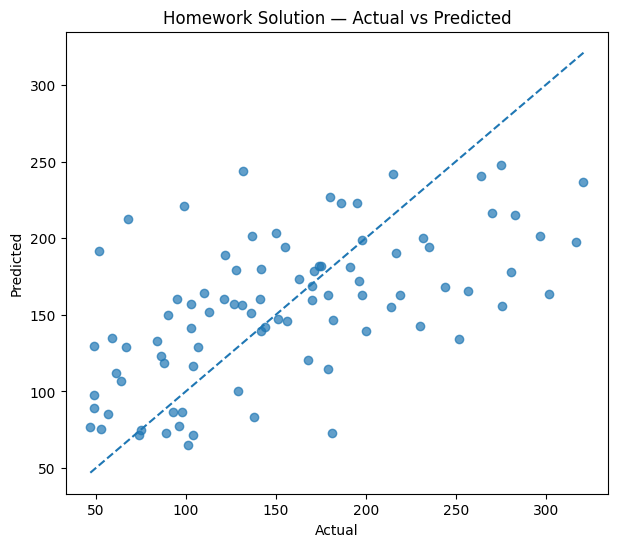

In [ ]:
# 9) Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test_hw, pred_hw, alpha=0.7)

min_val = min(y_test_hw.min(), pred_hw.min())
max_val = max(y_test_hw.max(), pred_hw.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Homework Solution — Actual vs Predicted")
plt.show()

<div class="fa-rtl" dir="rtl">

### 10) Interpretation پیشنهادی Homework

با `random_state=0`:

- Baseline MAE تقریباً **59.23**
- مدل سه‌متغیره MAE تقریباً **46.46**
- R² تقریباً **0.334**

تفسیر:

> مدل Linear Regression با استفاده از `bmi`, `bp`, `s5` از Mean Baseline بهتر عمل می‌کند، چون Test MAE به‌وضوح کمتر است. R² مثبت است و نشان می‌دهد مدل نسبت به Mean Baseline اطلاعات مفیدی از Featureها استخراج کرده است. با این حال بخش قابل‌توجهی از variation هدف هنوز توضیح داده نشده است. بنابراین مدل مفید است ولی performance آن کامل نیست و نباید فقط بر اساس R² نتیجه‌گیری قطعی انجام داد.

</div>

<div class="fa-rtl" dir="rtl">

# 3. Simple Linear Regression

حالا همان تمرین `bmi` را از یک «workflow» ساده به یک مدل قابل‌تفسیر تبدیل می‌کنیم.

در Simple Linear Regression:

$$
\hat{y} = b_0 + b_1x
$$

- `b0` = Intercept
- `b1` = Coefficient / Slope
- `x` = Predictor
- `ŷ` = Prediction

</div>

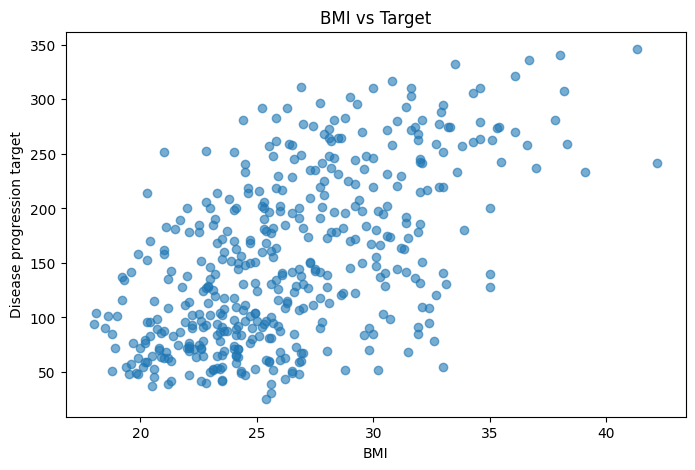

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["target"], alpha=0.6)
plt.xlabel("BMI")
plt.ylabel("Disease progression target")
plt.title("BMI vs Target")
plt.show()

In [37]:
# STEP 1 — Define X and y
X_one = df[["bmi"]]
y_one = df["target"]

X_one.head()

X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(
    X_one,
    y_one,
    test_size=0.2,
    random_state=0
)

print("Train shape:", X_train_one.shape)
print("Test shape:", X_test_one.shape)



simple_model = LinearRegression()
simple_model.fit(X_train_one, y_train_one)

print(f"Intercept: {simple_model.intercept_:.3f}")
print(f"BMI coefficient: {simple_model.coef_[0]:.3f}")

Train shape: (353, 1)
Test shape: (89, 1)
Intercept: -126.778
BMI coefficient: 10.580


In [ ]:
LinearRegression().fit(X_train_one, y_train_one).intercept_

np.float64(-126.77820035769682)

<div class="fa-rtl" dir="rtl">

## تفسیر Coefficient در Simple Regression

Coefficient مربوط به `bmi` تقریباً **10.58** است.

Interpretation:

> در این مدل تک‌متغیره، به‌طور متوسط افزایش **یک واحد BMI** با حدود **10.58 واحد افزایش در Target پیش‌بینی‌شده** همراه است.

کلمه مهم:

**همراه است**

نه:

**باعث می‌شود**

چون Regression Coefficient در یک Dataset مشاهده‌ای به‌تنهایی Causation را ثابت نمی‌کند.

</div>

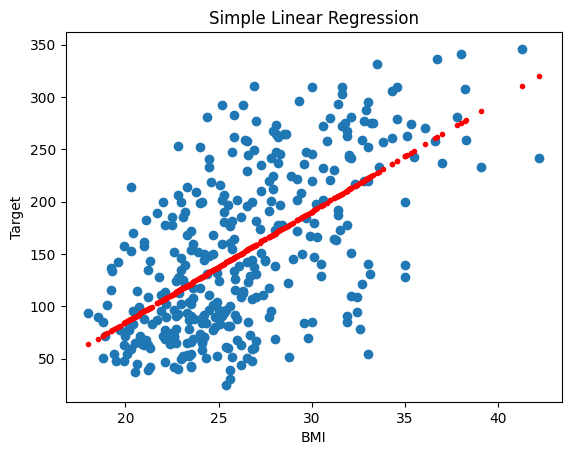

In [ ]:
# Plot for training data

plt.scatter(X_train_one["bmi"], y_train_one)

plt.plot(
    X_train_one["bmi"],
    simple_model.predict(X_train_one),
    "r."
)

plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple Linear Regression")

plt.show()

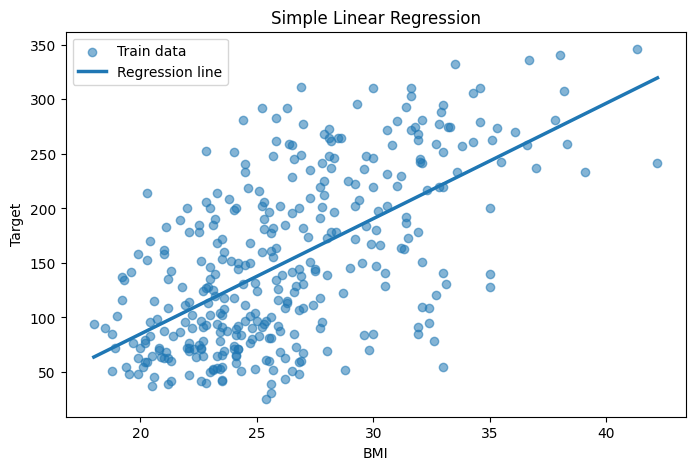

In [ ]:
# Better visualization

x_line = np.linspace(df["bmi"].min(), df["bmi"].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(
    pd.DataFrame(x_line, columns=["bmi"])
)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_one["bmi"], y_train_one, alpha=0.55, label="Train data")
plt.plot(x_line[:, 0], y_line, linewidth=2.5, label="Regression line")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

<div class="fa-rtl" dir="rtl">

# 4. Residuals و Least Squares

برای هر Observation:

$$
Residual = y - \hat{y}
$$

Linear Regression با روش Ordinary Least Squares تلاش می‌کند:

$$
\sum (y_i - \hat{y}_i)^2
$$

را کمینه کند.

یعنی مدلی پیدا کند که **مجموع مربع خطاها** کمترین مقدار ممکن را داشته باشد.

</div>

In [ ]:
#TESTING DATA
#TESTING DATA


y_pred_one = simple_model.predict(X_test_one)

simple_test_results = pd.DataFrame({
    "actual": y_test_one.values,
    "predicted": y_pred_one
})

simple_test_results["residual"] = (
    simple_test_results["actual"]
    - simple_test_results["predicted"]
)

display(simple_test_results.head(10).round(2))

,actual,predicted,residual
0,321.0,255.17,65.83
1,215.0,211.79,3.21
2,127.0,161.01,-34.01
3,64.0,129.27,-65.27
4,175.0,196.98,-21.98
5,275.0,247.77,27.23
6,179.0,123.98,55.02
7,232.0,174.76,57.24
8,142.0,205.45,-63.45
9,99.0,198.04,-99.04


<div class="fa-rtl" dir="rtl">

### Quiz

اگر:

- Actual = 180
- Predicted = 150

Residual چیست؟

<details>
<summary><b>پاسخ</b></summary>

```text
Residual = Actual - Predicted
         = 180 - 150
         = 30
```

Residual مثبت یعنی Model مقدار واقعی را **کمتر از واقعیت** پیش‌بینی کرده است.

</details>

</div>

<div class="fa-rtl" dir="rtl">

# 5. Multiple Linear Regression

در Multiple Linear Regression بیش از یک Predictor داریم:

$$
\hat{y}
=
b_0
+
b_1x_1
+
b_2x_2
+
\dots
+
b_px_p
$$

اینجا از همان سه Feature Homework استفاده می‌کنیم:

- `bmi`
- `bp`
- `s5`



</div>

In [ ]:
multi_features = ["bmi", "bp", "s5"]

X_multi = df[multi_features]
y_multi = df["target"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=0
)

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)

pred_multi = multi_model.predict(X_test_multi)

In [ ]:
coefficient_table = pd.DataFrame({
    "feature": multi_features,
    "coefficient": multi_model.coef_
})

print(f"Intercept: {multi_model.intercept_:.3f}")
#print("Intercept:", round(multi_model.intercept_, 3))
display(coefficient_table.round(3))

Intercept: -339.424
Intercept: -339.424


,feature,coefficient
0,bmi,6.878
1,bp,0.770
2,s5,51.130


In [ ]:
multi_model.coef_
#multi_model.coef_.round(2)

array([ 6.88,  0.77, 51.13])

<div class="fa-rtl" dir="rtl">

# 6. Coefficient Interpretation در Multiple Regression

در Multiple Regression، Coefficient هر Feature نشان می‌دهد با افزایش یک واحد در آن Feature، Prediction چقدر تغییر می‌کند، **در حالی که سایر Featureهای مدل ثابت نگه داشته شده‌اند.**

مثلاً اگر coefficient مربوط به `bmi` برابر `6.88` باشد:

> با ثابت نگه داشتن `bp` و `s5`، افزایش یک واحد BMI با حدود 6.88 واحد افزایش در Target پیش‌بینی‌شده همراه است.

اگر coefficient مربوط به `bp` برابر `0.77` باشد:

> با ثابت نگه داشتن `bmi` و `s5`، افزایش یک واحد BP با حدود 0.77 واحد افزایش در Target پیش‌بینی‌شده همراه است.

### سؤال مهم

چرا coefficient مربوط به BMI در Simple Model و Multiple Model یکسان نیست؟

<details>

<summary><b>پاسخ</b></summary>

در Simple Regression فقط BMI در مدل است، بنابراین تمام association بین BMI و Target به BMI نسبت داده می‌شود.

اما در Multiple Regression، `bp` و `s5` هم وارد مدل می‌شوند. اگر این Featureها با BMI مرتبط باشند، بخشی از association بین BMI و Target توسط آن‌ها توضیح داده می‌شود.

به همین دلیل coefficient مربوط به BMI ممکن است تغییر کند.

</details>

</div>


<div class="fa-rtl" dir="rtl">

## Coefficient بزرگ‌تر = Feature مهم‌تر؟

**نه لزوماً.**

Magnitude ضریب به Scale متغیر وابسته است.

مثلاً:

- `bmi` یک Scale دارد.
- `bp` Scale دیگری دارد.
- `s5` Scale متفاوتی دارد.

بنابراین مقایسه مستقیم قدرمطلق coefficientها برای Feature Importance می‌تواند گمراه‌کننده باشد.

بعداً درباره:

- Standardization
- Permutation Importance
- SHAP

صحبت خواهیم کرد.

</div>

<div class="fa-rtl" dir="rtl" style="font-family: Tahoma, Arial, sans-serif; line-height: 1.9; font-size: 16px;">

# 7. Before Trusting a Linear Regression Model

قبل از اینکه نتیجه Linear Regression را تفسیر کنیم، بهتر است چند نکته را بررسی کنیم:

1. **آیا رابطه تقریباً خطی است؟**
   Linear Regression برای رابطه‌های تقریباً خطی مناسب‌تر است.

2. **آیا خطاها الگوی خاصی دارند؟**
   Residualها بهتر است به‌صورت نسبتاً Random اطراف صفر پخش باشند.


3. **آیا Observationها مستقل هستند؟**
   مثلاً چند Measurement از یک فرد ممکن است کاملاً مستقل نباشند.

4. **آیا Predictorها بیش از حد شبیه هم هستند؟**
   Correlation خیلی زیاد بین Predictorها می‌تواند تفسیر Coefficientها را مشکل کند.

> هدف این بررسی‌ها این است که مطمئن شویم Linear Regression برای داده ما انتخاب معقولی است و Interpretation آن گمراه‌کننده نیست.

</div>


<div class="fa-rtl" dir="rtl" style="font-family: Tahoma, Arial, sans-serif; line-height: 1.9; font-size: 16px;">

## 7.1 بررسی Linearity و Pattern خطاها

بعد از ساخت مدل، یکی از اولین چیزهایی که بررسی می‌کنیم **Residualها** هستند.

Residual یعنی:

> مقدار واقعی − مقدار پیش‌بینی‌شده

برای بررسی بهتر، Residualها را در برابر Predictionهای مدل رسم می‌کنیم.

اگر نقاط به‌صورت نسبتاً تصادفی اطراف خط صفر پخش شده باشند، وضعیت مناسب‌تر است.

اما اگر:

* یک **Curve** واضح ببینیم → ممکن است رابطه کاملاً Linear نباشد.

هدف این Plot این است که ببینیم آیا Errorهای مدل Pattern مشخصی دارند یا نه.

</div>


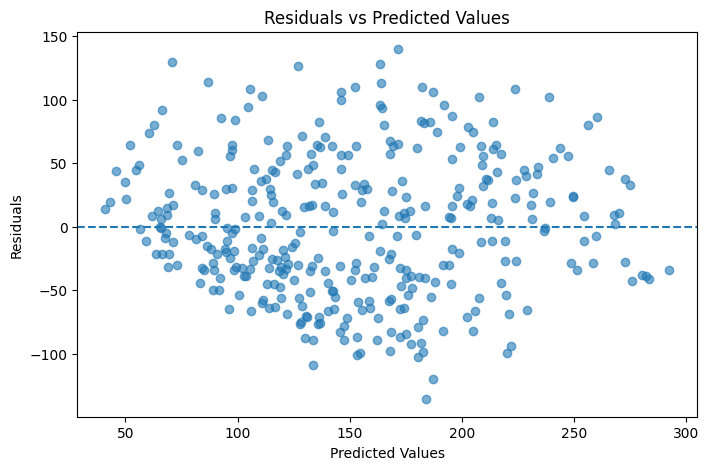

In [ ]:
# Predictions on training data
train_pred = multi_model.predict(X_train_multi)

# Residuals = Actual - Predicted
residuals = y_train_multi - train_pred

# Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(train_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

<div class="fa-rtl" dir="rtl" style="font-family: Tahoma, Arial, sans-serif; line-height: 1.9; font-size: 16px;">

### چطور نمودار را بخوانیم؟

* نقاط بهتر است به‌صورت نسبتاً Random اطراف خط صفر پخش باشند.
* اگر یک **Curve** واضح ببینیم، ممکن است رابطه کاملاً Linear نباشد.


> هدف این نمودار این است که ببینیم آیا Errorهای مدل Pattern مشخصی دارند یا نه.

</div>


<div class="fa-rtl" dir="rtl">

## 7.2 Multicollinearity

اگر دو Predictor اطلاعات بسیار مشابه داشته باشند، Coefficientها ممکن است ناپایدار شوند.

در Dataset Diabetes ممکن است بعضی Serum Measurementها با یکدیگر Correlated باشند.

در **Session 3** این موضوع را با:

- Correlation
- VIF
- Feature Selection
- Lasso

دقیق بررسی می‌کنیم.

</div>

<div class="fa-rtl" dir="rtl">

# 8. Pearson Correlation

Pearson عمدتاً شدت و جهت **Linear Association** را اندازه می‌گیرد.

مقدار:

$$
-1 \le r \le 1
$$

- نزدیک `+1` → Linear association مثبت قوی
- نزدیک `-1` → Linear association منفی قوی
- نزدیک `0` → Linear association ضعیف

</div>

In [ ]:
from scipy.stats import pearsonr

pearson_bmi_r, pearson_bmi_p = pearsonr(
    df["bmi"],
    df["target"]
)

print(f"Pearson r (BMI vs Target): {pearson_bmi_r:.3f}")
print(f"p-value: {pearson_bmi_p:.3e}")

0.5864501344746887
3.4660064451669974e-42


<div class="fa-rtl" dir="rtl">

در این Dataset، BMI و Target یک Pearson Correlation مثبت دارند.

اما:

> مقدار p-value کوچک یا correlation بالا، Causation را ثابت نمی‌کند.

p-value درباره ناسازگاری داده با فرض صفر آماری اطلاعات می‌دهد؛ نه درباره اثبات علت و معلول.

</div>

<div class="fa-rtl" dir="rtl">




correlation coefficient می‌گوید رابطه چقدر قوی است؛ p-value می‌گوید آیا این رابطه احتمالاً فقط ناشی از شانس است یا نه.
</div>

<div class="fa-rtl" dir="rtl">

# 9. Spearman Correlation

Spearman بر اساس **Rank**ها کار می‌کند و association **Monotonic** را اندازه می‌گیرد.

برای شرایطی مفید است که:

- رابطه Monotonic ولی دقیقاً Linear نیست.
- Outlierها مسئله‌سازند.
- Ranking برای ما مهم‌تر از فاصله عددی دقیق است.

</div>

<div class="fa-rtl" dir="rtl" style="font-family: Tahoma, Arial, sans-serif; line-height: 1.9; font-size: 16px;">

> ### Rank یعنی چه؟
>
> Rank یعنی به‌جای استفاده از خود مقدارها، فقط **ترتیب آن‌ها از کوچک به بزرگ** را در نظر بگیریم.
>
> مثال:
>
> ```text
> BMI:   22   25   30   35
> Rank:   1    2    3    4
> ```
>
> Spearman بیشتر بررسی می‌کند که آیا **ترتیب دو متغیر با هم هماهنگ است یا نه**.
>
> یعنی اگر مقدار یک Variable بیشتر شود، آیا Variable دیگر هم معمولاً در همان جهت تغییر می‌کند؟
>
> به زبان ساده:
>
> **Pearson با مقدارهای واقعی کار می‌کند، ولی Spearman بیشتر با ترتیب یا Rank مقدارها کار می‌کند.**

</div>


In [ ]:
from scipy.stats import spearmanr

spearman_bmi_r, spearman_bmi_p = spearmanr(
    df["bmi"],
    df["target"]
)

print(f"Spearman rho (BMI vs Target): {spearman_bmi_r:.3f}")
print(f"p-value: {spearman_bmi_p:.3e}")

Spearman rho (BMI vs Target): 0.561
p-value: 4.567e-38


In [ ]:
# Compare Pearson and Spearman for several real features
corr_comparison = []

for feature in ["age", "bmi", "bp", "s5", "s6"]:
    p_r, _ = pearsonr(df[feature], df["target"])
    s_r, _ = spearmanr(df[feature], df["target"])

    corr_comparison.append({
        "feature": feature,
        "Pearson": p_r,
        "Spearman": s_r
    })

display(pd.DataFrame(corr_comparison).round(3))

,feature,Pearson,Spearman
0,age,0.188,0.198
1,bmi,0.586,0.561
2,bp,0.441,0.416
3,s5,0.566,0.589
4,s6,0.382,0.351


<div class="fa-rtl" dir="rtl">

## Pearson vs Spearman

| موضوع | Pearson | Spearman |
|---|---|---|
| نوع association | Linear | Monotonic |
| استفاده از مقدار خام | بله | Rank |
| حساسیت به Outlier | بیشتر | معمولاً کمتر |
| مناسب برای Curve monotonic | محدودتر | مناسب‌تر |

> اگر Pearson نزدیک صفر باشد، نمی‌توان فوراً گفت «هیچ رابطه‌ای وجود ندارد». ممکن است رابطه Nonlinear باشد.

</div>

<div class="fa-rtl" dir="rtl">

# 10. Correlation Matrix

برای چند Variable می‌توانیم تمام Pairwise Correlationها را یکجا بررسی کنیم.

</div>

In [ ]:
#Pearson
corr_matrix = df.corr()

display(corr_matrix.round(2))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.00,0.17,0.19,0.34,0.26,0.22,-0.08,0.20,0.27,0.30,0.19
sex,0.17,1.00,0.09,0.24,0.04,0.14,-0.38,0.33,0.15,0.21,0.04
bmi,0.19,0.09,1.00,0.40,0.25,0.26,-0.37,0.41,0.45,0.39,0.59
bp,0.34,0.24,0.40,1.00,0.24,0.19,-0.18,0.26,0.39,0.39,0.44
s1,0.26,0.04,0.25,0.24,1.00,0.90,0.05,0.54,0.52,0.33,0.21
s2,0.22,0.14,0.26,0.19,0.90,1.00,-0.20,0.66,0.32,0.29,0.17
s3,-0.08,-0.38,-0.37,-0.18,0.05,-0.20,1.00,-0.74,-0.40,-0.27,-0.39
s4,0.20,0.33,0.41,0.26,0.54,0.66,-0.74,1.00,0.62,0.42,0.43
s5,0.27,0.15,0.45,0.39,0.52,0.32,-0.40,0.62,1.00,0.46,0.57
s6,0.30,0.21,0.39,0.39,0.33,0.29,-0.27,0.42,0.46,1.00,0.38


In [ ]:
corr_matrix_spearman = df.corr(method="spearman")

display(corr_matrix.round(2))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.00,0.17,0.19,0.34,0.26,0.22,-0.08,0.20,0.27,0.30,0.19
sex,0.17,1.00,0.09,0.24,0.04,0.14,-0.38,0.33,0.15,0.21,0.04
bmi,0.19,0.09,1.00,0.40,0.25,0.26,-0.37,0.41,0.45,0.39,0.59
bp,0.34,0.24,0.40,1.00,0.24,0.19,-0.18,0.26,0.39,0.39,0.44
s1,0.26,0.04,0.25,0.24,1.00,0.90,0.05,0.54,0.52,0.33,0.21
s2,0.22,0.14,0.26,0.19,0.90,1.00,-0.20,0.66,0.32,0.29,0.17
s3,-0.08,-0.38,-0.37,-0.18,0.05,-0.20,1.00,-0.74,-0.40,-0.27,-0.39
s4,0.20,0.33,0.41,0.26,0.54,0.66,-0.74,1.00,0.62,0.42,0.43
s5,0.27,0.15,0.45,0.39,0.52,0.32,-0.40,0.62,1.00,0.46,0.57
s6,0.30,0.21,0.39,0.39,0.33,0.29,-0.27,0.42,0.46,1.00,0.38


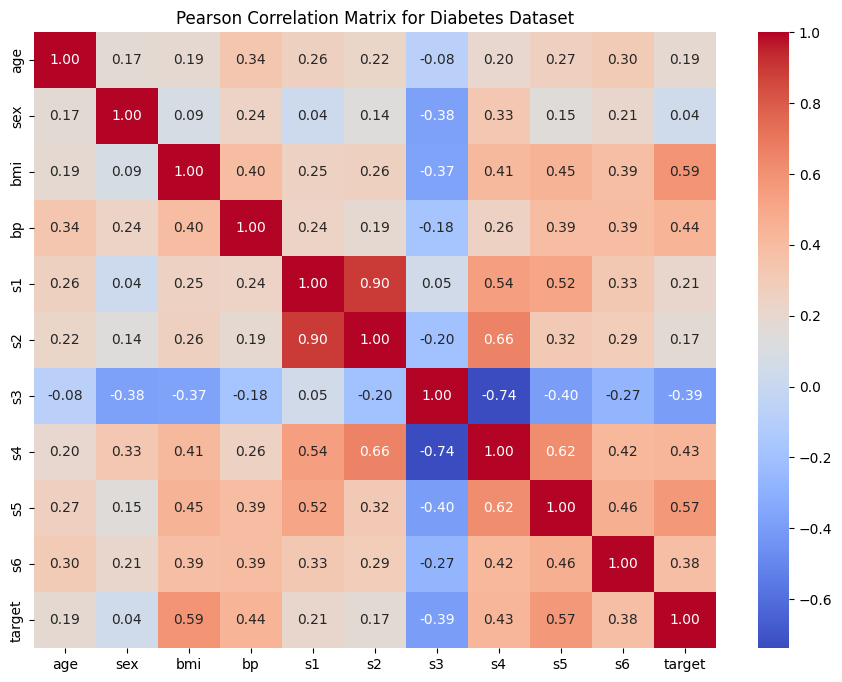

In [ ]:
plt.figure(figsize=(11, 8))
sns.heatmap(
#    corr_matrix_spearman,
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Pearson Correlation Matrix for Diabetes Dataset")
plt.show()

<div class="fa-rtl" dir="rtl">

## نکات مهم Heatmap

1. قطر اصلی همیشه `1` است.
2. Matrix متقارن است.
3. علامت ضریب جهت association را نشان می‌دهد.
4. قدرمطلق بزرگ‌تر یعنی association قوی‌تر از نوع Pearson.
5. Correlation بالا بین Predictorها می‌تواند Warning برای Multicollinearity باشد.

اما:

> Feature را فقط به دلیل Correlation کم با Target حذف نکنید.

چون ممکن است:

- relationship nonlinear باشد.
- Feature همراه با Featureهای دیگر مفید شود.
- Interaction وجود داشته باشد.

</div>

<div class="fa-rtl" dir="rtl">

# 11. Correlation vs Causation

از Dataset Diabetes ممکن است ببینیم:

`BMI ↔ Target`

با هم association دارند.

اما از همین Observational Dataset نمی‌توانیم نتیجه بگیریم:

> اگر BMI را یک واحد تغییر دهیم، Target دقیقاً به اندازه coefficient تغییر خواهد کرد.

چرا؟

ممکن است Confounderهایی مثل:

- Age
- Sex
- Blood pressure
- metabolic factors
- treatment history
- lifestyle

در association نقش داشته باشند.

### قانون

**Correlation / Regression association ≠ Causal effect**

</div>

<div class="fa-rtl" dir="rtl">

# 12. Regression Evaluation Metrics

چهار Metric رایج:

### MAE

$$
MAE =
\frac{1}{n}
\sum |y_i-\hat{y}_i|
$$

- واحد = واحد Target
- ساده و قابل‌تفسیر

### MSE

$$
MSE =
\frac{1}{n}
\sum (y_i-\hat{y}_i)^2
$$

- Errorهای بزرگ را بیشتر جریمه می‌کند.
- واحد آن مربع Target است.

### RMSE

$$
RMSE = \sqrt{MSE}
$$

- به واحد اصلی Target برمی‌گردد.
- به Errorهای بزرگ حساس‌تر از MAE است.

### R²

$$
R^2
=
1-
\frac{\sum(y_i-\hat y_i)^2}
{\sum(y_i-\bar y)^2}
$$

- `1` بهتر
- `0` تقریباً هم‌سطح Mean baseline
- می‌تواند روی Test Set **منفی** باشد.

</div>

![R2 Meaning](https://raw.githubusercontent.com/hamed-naseri/machine-learning-course-aut/main/images/r2%20meaning.png)

In [ ]:
# Same test split, three models:
# 1) Mean baseline
# 2) Simple LR with BMI
# 3) Multiple LR with BMI + BP + S5

baseline_final = DummyRegressor(strategy="mean")
baseline_final.fit(X_train_multi, y_train_multi)
pred_baseline_final = baseline_final.predict(X_test_multi)

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

metrics_table = pd.DataFrame([
    {
        "Model": "Mean Baseline",
        **regression_metrics(y_test_multi, pred_baseline_final)
    },
    {
        "Model": "Simple LR — BMI",
        **regression_metrics(y_test_one, y_pred_one)
    },
    {
        "Model": "Multiple LR — BMI + BP + S5",
        **regression_metrics(y_test_multi, pred_multi)
    }
])

display(metrics_table.round(3))

,Model,MAE,MSE,RMSE,R2
0,Mean Baseline,59.227,5134.784,71.657,-0.001
1,Simple LR — BMI,52.944,4150.680,64.426,0.191
2,Multiple LR — BMI + BP + S5,46.458,3417.638,58.461,0.334


<div class="fa-rtl" dir="rtl">

## چطور Metrics را گزارش کنیم؟

بهتر است فقط یک عدد گزارش نکنیم.

مثلاً:

> Multiple Linear Regression نسبت به Mean Baseline MAE کمتری داشت. همچنین نسبت به مدل تک‌متغیره BMI بهتر عمل کرد. RMSE بزرگ‌تر از MAE است، که نشان می‌دهد بعضی Errorهای بزرگ‌تر روی RMSE اثر بیشتری دارند. R² مثبت است، اما هنوز فاصله قابل‌توجهی تا 1 دارد.

### نکته مهم

`R² = 0.33`

یعنی:

**نه** اینکه «مدل 33٪ Predictionها را درست گفته».

R² یک Accuracy Percentage نیست.

</div>

<div class="fa-rtl" dir="rtl">

# 13. تمرین جلسه دوم

این بار Feature اصلی شما:

`bp`

است.

### Part A — Simple Regression

1. `X = bp`
2. `y = target`
3. Split با `random_state=0`
4. Baseline
5. Linear Regression
6. Coefficient
7. MAE
8. RMSE
9. R²
10. یک جمله Interpretation

### Part B — Correlation

برای `bp` و `target`:

1. Pearson
2. Spearman
3. Scatter Plot
4. آیا از نتیجه می‌توان Causation نتیجه گرفت؟

</div>

In [ ]:
# =========================
# TODO — Part A
# =========================

# X_ex = df[["bp"]]
# y_ex = df["target"]

# X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
#     X_ex,
#     y_ex,
#     test_size=0.2,
#     random_state=0
# )

# baseline_ex = DummyRegressor(strategy="mean")
# ...

In [ ]:
# =========================
# TODO — Part B
# =========================

# pearson_ex, pearson_p_ex = pearsonr(...)
# spearman_ex, spearman_p_ex = spearmanr(...)

# plt.scatter(...)

<div class="fa-rtl" dir="rtl">

<details>
<summary><b>نمونه پاسخ تمرین جلسه دوم</b></summary>

```python
# Part A
X_ex = df[["bp"]]
y_ex = df["target"]

X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_ex,
    y_ex,
    test_size=0.2,
    random_state=0
)

baseline_ex = DummyRegressor(strategy="mean")
baseline_ex.fit(X_train_ex, y_train_ex)
pred_base_ex = baseline_ex.predict(X_test_ex)

model_ex = LinearRegression()
model_ex.fit(X_train_ex, y_train_ex)
pred_ex = model_ex.predict(X_test_ex)

mse_ex = mean_squared_error(y_test_ex, pred_ex)

print("Coefficient:", model_ex.coef_[0])
print("Baseline MAE:", mean_absolute_error(y_test_ex, pred_base_ex))
print("Model MAE:", mean_absolute_error(y_test_ex, pred_ex))
print("RMSE:", np.sqrt(mse_ex))
print("R²:", r2_score(y_test_ex, pred_ex))

# Part B
pearson_ex, _ = pearsonr(df["bp"], df["target"])
spearman_ex, _ = spearmanr(df["bp"], df["target"])

print("Pearson:", pearson_ex)
print("Spearman:", spearman_ex)

plt.scatter(df["bp"], df["target"], alpha=0.6)
plt.xlabel("Blood pressure")
plt.ylabel("Target")
plt.show()
```

Interpretation:

> BP و Target association مثبت دارند، اما این association به‌تنهایی اثر علّی BP را ثابت نمی‌کند.
```

</details>

</div>

<div class="fa-rtl" dir="rtl">

# 14. Exit Quiz

1. Simple و Multiple Linear Regression چه تفاوتی دارند؟
2. Coefficient در Multiple Regression را چگونه تفسیر می‌کنیم؟
3. Residual چیست؟
4. Least Squares چه چیزی را کمینه می‌کند؟
5. Curve در Residual-vs-Fitted چه Warningی می‌دهد؟
6. Pearson چه نوع association را اندازه می‌گیرد؟
7. Spearman چه نوع association را اندازه می‌گیرد؟
8. آیا Correlation بالا Causation را ثابت می‌کند؟
9. MAE کمتر بهتر است یا بیشتر؟
10. چرا RMSE نسبت به Errorهای بزرگ حساس‌تر است؟
11. آیا R² می‌تواند منفی شود؟

</div>

<div class="fa-rtl" dir="rtl">

<details>
<summary><b>پاسخ Exit Quiz</b></summary>

1. Simple یک Predictor دارد؛ Multiple بیش از یک Predictor.
2. تغییر Prediction به ازای یک واحد تغییر Feature، با ثابت نگه داشتن سایر Predictorهای Model.
3. `Actual - Predicted`
4. مجموع مربع Residualها.
5. احتمال Nonlinearity.
6. Linear association.
7. Monotonic association بر اساس Rank.
8. خیر.
9. کمتر.
10. چون Errorها مربع می‌شوند.
11. بله.

</details>

</div>

<div class="fa-rtl" dir="rtl">

# جمع‌بندی جلسه

امروز یک مسیر پیوسته داشتیم:

```text
Session 1 Workflow
        ↓
Solve Homework
        ↓
Simple Regression
        ↓
Coefficients
        ↓
Multiple Regression
        ↓
Residual Diagnostics
        ↓
Pearson / Spearman
        ↓
Correlation Matrix
        ↓
Correlation ≠ Causation
        ↓
Regression Metrics
```

### سه پیام اصلی

**1.** در Multiple Regression، Coefficient هر Predictor conditional on the other predictors است.

**2.** Correlation و Regression association، Causation را به‌تنهایی ثابت نمی‌کنند.

**3.** Model را فقط `fit` نکنید؛ روی Test Data ارزیابی و Residualها را بررسی کنید.

### جلسه بعد

**Multicollinearity & Feature Selection**

- VIF
- Redundant Features
- Correlation-based Selection
- Variance Threshold
- Mutual Information
- RFE
- Lasso-based Selection
- Tree-based Feature Importance

</div>